<a href="https://colab.research.google.com/github/batoolrabia888-ctrl/Rabia-Batool/blob/main/Google_playstore_Apps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
# load data
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


In [52]:
# convertion of dtype(object into numeric)
df['Reviews'] = pd.to_numeric(df['Reviews'],errors = 'coerce')
df['Installs'] = pd.to_numeric(df['Installs'],errors = 'coerce')
df['Price'] = pd.to_numeric(df['Price'],errors = 'coerce')

In [53]:
# to check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10840 non-null  float64
 4   Size            10841 non-null  object 
 5   Installs        1804 non-null   float64
 6   Type            10840 non-null  object 
 7   Price           10040 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(4), object(9)
memory usage: 1.1+ MB


In [54]:
# check NAN from price
df['Price'] = df['Price'].fillna(0)
df['Installs'] = df['Installs'].fillna(0)


In [55]:
# check average rating
df['Rating'].mean()

np.float64(4.193338315362443)

In [56]:
df['Rating'].count()

np.int64(9367)

In [57]:
# money maker apps
df['revenue'] = df['Price']*df['Installs']
df.sort_values(by = 'revenue',ascending=False).head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,revenue
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307.0,19M,0.0,Free,0.0,Everyone,Lifestyle,25-Jul-18,Varies with device,Varies with device,0.0
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,0.0,Free,0.0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up,0.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,0.0,Free,0.0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,0.0,Free,0.0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up,0.0
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,0.0,Free,0.0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up,0.0


In [58]:
# top 10 categories
# data visualization

In [60]:
# Sirf wo rows rakhein jahan rating 5 ya us se kam ho
df = df[df['Rating'] <= 5]

# Phir se graph banayein
top_categories = df['Category'].value_counts().head(10)
# ... baqi graph ka code

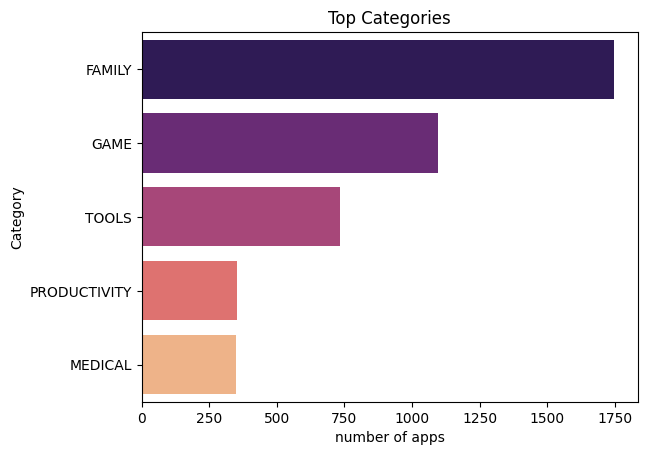

In [64]:
top_categories = df['Category'].value_counts().head()
sns.barplot(x = top_categories.values , y = top_categories.index, hue = top_categories.index, palette = 'magma', legend = False )
plt.title('Top Categories')
plt.xlabel('number of apps')
plt.ylabel('Category')
plt.show()

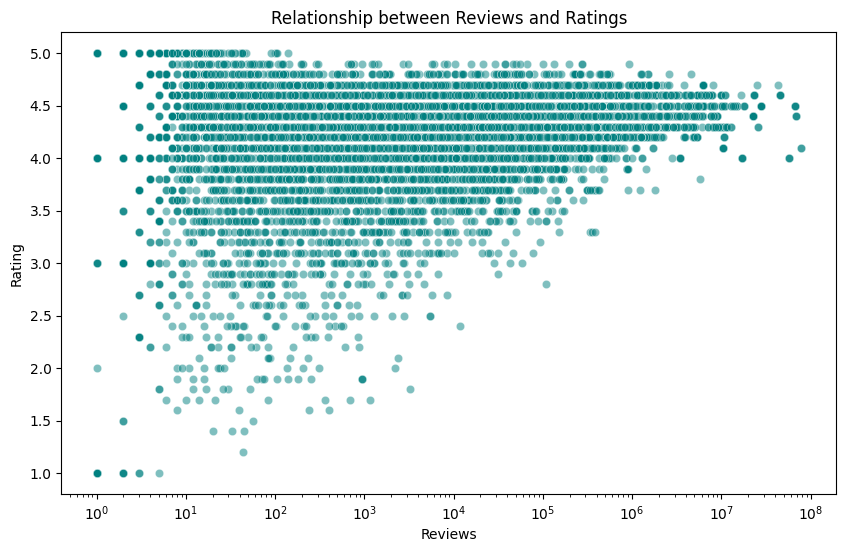

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
# Scatter plot reviews vs rating
sns.scatterplot(data=df, x='Reviews', y='Rating', alpha=0.5, color='teal')

plt.title('Relationship between Reviews and Ratings')
plt.xscale('log') # Kyunke reviews millions mein hain, 'log' scale se graph saaf dikhega
plt.show()